In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import xgboost as xgb


In [3]:
sample = pd.read_csv('sample_submission.csv')
train = pd.read_csv('train.csv')
train.drop(columns=['id'], inplace=True)
test = pd.read_csv('test.csv')


ORIG = pd.read_csv('diabetes_dataset.csv')

train.shape, test.shape, sample.shape, ORIG.shape

((700000, 25), (300000, 25), (300000, 2), (100000, 31))

If the msno.matrix plot shows all bars fully grey, that generally means there are no missing values (grey = present, white = missing). It can also be caused by rendering size/scale — the matrix shows present values as solid lines. Use the diagnostic cell below to confirm.

Total missing per column:


age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
diagnosed_diabetes                    0



Proportion missing per column:


age                                   0.0
alcohol_consumption_per_week          0.0
physical_activity_minutes_per_week    0.0
diet_score                            0.0
sleep_hours_per_day                   0.0
screen_time_hours_per_day             0.0
bmi                                   0.0
waist_to_hip_ratio                    0.0
systolic_bp                           0.0
diastolic_bp                          0.0
heart_rate                            0.0
cholesterol_total                     0.0
hdl_cholesterol                       0.0
ldl_cholesterol                       0.0
triglycerides                         0.0
gender                                0.0
ethnicity                             0.0
education_level                       0.0
income_level                          0.0
smoking_status                        0.0
employment_status                     0.0
family_history_diabetes               0.0
hypertension_history                  0.0
cardiovascular_history            

<Figure size 1400x600 with 0 Axes>

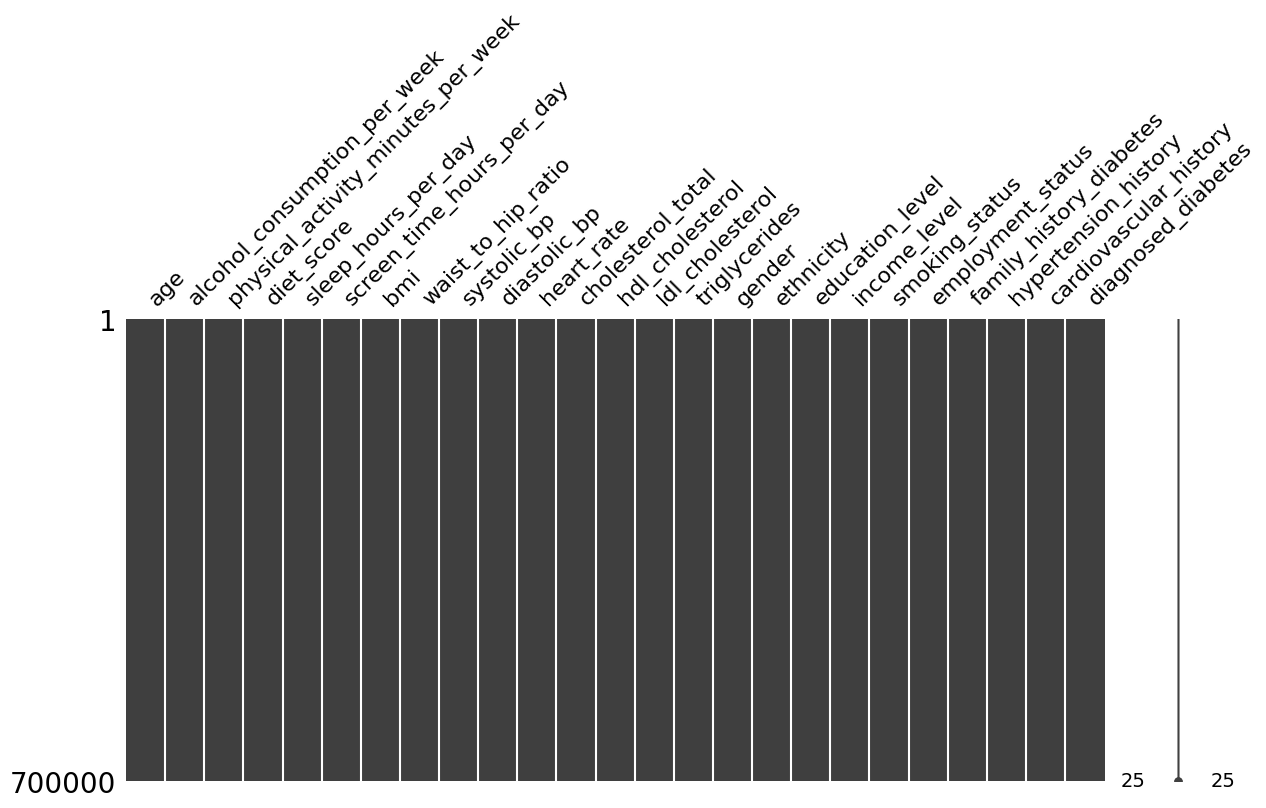

In [3]:
# Diagnostic checks for missingness
print('Total missing per column:')
display(train.isnull().sum())
print('\nProportion missing per column:')
display((train.isnull().mean()).round(4))

# Larger/sorted matrix to highlight structure (if any missing exists)
plt.figure(figsize=(14,6))
msno.matrix(train, figsize=(14,6), sort='ascending')
plt.show()

In [5]:
NUMS = ['age','alcohol_consumption_per_week','physical_activity_minutes_per_week','diet_score','sleep_hours_per_day','screen_time_hours_per_day','bmi','waist_to_hip_ratio','systolic_bp','diastolic_bp','heart_rate','cholesterol_total','hdl_cholesterol','ldl_cholesterol','triglycerides','family_history_diabetes','hypertension_history','cardiovascular_history']
CAT = ['gender','ethnicity','education_level','income_level','smoking_status','employment_status']
TARGET = 'diagnosed_diabetes'

In [6]:
for cat in CAT:
    print(f"Cardinality of {cat}: {train[cat].nunique()} and values: {train[cat].unique()}")


Cardinality of gender: 3 and values: ['Female' 'Male' 'Other']
Cardinality of ethnicity: 5 and values: ['Hispanic' 'White' 'Asian' 'Black' 'Other']
Cardinality of education_level: 4 and values: ['Highschool' 'Graduate' 'Postgraduate' 'No formal']
Cardinality of income_level: 5 and values: ['Lower-Middle' 'Upper-Middle' 'Low' 'Middle' 'High']
Cardinality of smoking_status: 3 and values: ['Current' 'Never' 'Former']
Cardinality of employment_status: 4 and values: ['Employed' 'Retired' 'Student' 'Unemployed']


In [7]:
# value counts of categorical variables
for cat in CAT:
    print(f"\nValue counts for {cat}:")
    print(train[cat].value_counts())
    print(f'Proportions: {train[cat].value_counts(normalize=True)*100}')


Value counts for gender:
gender
Female    363237
Male      333085
Other       3678
Name: count, dtype: int64
Proportions: gender
Female    51.891000
Male      47.583571
Other      0.525429
Name: proportion, dtype: float64

Value counts for ethnicity:
ethnicity
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: count, dtype: int64
Proportions: ethnicity
White       55.164714
Hispanic    18.569143
Black       15.185857
Asian        8.588571
Other        2.491714
Name: proportion, dtype: float64

Value counts for education_level:
education_level
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: count, dtype: int64
Proportions: education_level
Highschool      49.163571
Graduate        37.324000
Postgraduate    11.377429
No formal        2.135000
Name: proportion, dtype: float64

Value counts for income_level:
income_level
Middle          290557
Lower-Middle    178570
Upper-Middle    127836
Lo

In [6]:
train["bmi_bin"] = pd.cut(
    train["bmi"],
    bins=[0, 25, 30, 100],
    labels=["normal", "overweight", "obese"]
)
test["bmi_bin"] = pd.cut(
    test["bmi"],
    bins=[0, 25, 30, 100],
    labels=["normal", "overweight", "obese"]
)
CAT.append("bmi_bin")

train["age_bin"] = pd.cut(
    train["age"],
    bins=[0, 40, 50, 60, 120],
    labels=["<40", "40-50", "50-60", "60+"]
)
test["age_bin"] = pd.cut(
    test["age"],
    bins=[0, 40, 50, 60, 120],
    labels=["<40", "40-50", "50-60", "60+"]
)
CAT.append("age_bin")

train["activity_clipped"] = train["physical_activity_minutes_per_week"].clip(0, 300)
train["activity_bin"] = pd.cut(
    train["activity_clipped"],
    bins=[0, 60, 150, 1000],
    labels=["low", "moderate", "high"]
)
test["activity_clipped"] = test["physical_activity_minutes_per_week"].clip(0, 300)
test["activity_bin"] = pd.cut(
    test["activity_clipped"],
    bins=[0, 60, 150, 1000],
    labels=["low", "moderate", "high"]
)
CAT.append("activity_bin")

In [7]:
# Create factorized pairwise interaction features (numeric codes) using combined factorize
interaction_cols = []
for col in ["bmi_bin", "age_bin", "activity_bin"]:
    name = f'{col}_x_fh'
    # build combined string in train and test
    train[name] = train[col].astype(str) + '_' + train['family_history_diabetes'].astype(str)
    test[name] = test[col].astype(str) + '_' + test['family_history_diabetes'].astype(str)
    # factorize across the concatenated series so train/test share codes
    combined = pd.concat([train[name], test[name]], ignore_index=True)
    codes, uniques = pd.factorize(combined)
    # Drop feature if cardinality is too high (more than 50% unique values)
    if pd.Series(codes).nunique() > len(codes) // 2:
        train = train.drop(columns=[name])
        test = test.drop(columns=[name])
        print(f'Dropped {name} due to high cardinality')
        continue
    # split codes back into train/test and store as numeric factor columns
    train[f'{name}_fact'] = codes[:len(train)]
    test[f'{name}_fact'] = codes[len(train):len(train) + len(test)]
    interaction_cols.append(f'{name}_fact')
    # remove the temporary string columns
    train.drop(columns=[name], inplace=True)
    test.drop(columns=[name], inplace=True)
# Add factorized interaction columns to NUMS so they are processed by the numeric pipeline
NUMS.extend(interaction_cols)
print('Added interaction numeric cols to NUMS:', interaction_cols)


Added interaction numeric cols to NUMS: ['bmi_bin_x_fh_fact', 'age_bin_x_fh_fact', 'activity_bin_x_fh_fact']


In [8]:
from sklearn.model_selection import StratifiedKFold

def kfold_target_encode(train, test, col, target, n_splits=5, smooth=10):

    global_mean = train[target].mean()
    train_te = pd.Series(index=train.index, dtype=np.float32)
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for tr_idx, val_idx in skf.split(train, train[target]):
        tr, val = train.iloc[tr_idx], train.iloc[val_idx]

        stats = tr.groupby(col)[target].agg(['mean', 'count'])
        means = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)

        train_te.iloc[val_idx] = val[col].map(means)

    train_te.fillna(global_mean, inplace=True)

    # test encoding uses full train
    stats = train.groupby(col)[target].agg(['mean', 'count'])
    means = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
    test_te = test[col].map(means).fillna(global_mean)

    return train_te, test_te


In [10]:
for col in interaction_cols:
    train[f'TE_{col}'], test[f'TE_{col}'] = kfold_target_encode(
        train,
        test,
        col=col,
        target=TARGET,
        n_splits=5,
        smooth=20 
    )

NUMS.extend([f'TE_{col}' for col in interaction_cols])

C:\Users\as\AppData\Local\Temp\ipykernel_1404\939589316.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.5270503  0.60396561 0.88108959 ... 0.5270503  0.84070897 0.60396561]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  train_te.iloc[val_idx] = val[col].map(means)
C:\Users\as\AppData\Local\Temp\ipykernel_1404\939589316.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.55052634 0.60677184 0.92066831 ... 0.47282591 0.88177018 0.47282591]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  train_te.iloc[val_idx] = val[col].map(means)
C:\Users\as\AppData\Local\Temp\ipykernel_1404\939589316.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.559

In [27]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Ordered categories (must match your data labels exactly)
edu_categories = [['No formal', 'Highschool', 'Graduate', 'Postgraduate']]
inc_categories = [['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']]
bmi_categories = [['normal', 'overweight', 'obese']]
age_categories = [['<40', '40-50', '50-60', '60+']]
activity_categories = [['low', 'moderate', 'high']]
# Numeric pipeline: impute then scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Ordinal pipelines for ordered categorical features
education_pipeline = Pipeline([
    ('ord', OrdinalEncoder(categories=edu_categories, dtype=np.int32))
])
income_pipeline = Pipeline([
    ('ord', OrdinalEncoder(categories=inc_categories, dtype=np.int32))
])
bmi_pipeline = Pipeline([
    ('ord', OrdinalEncoder(categories=bmi_categories, dtype=np.int32))
])
age_pipeline = Pipeline([
    ('ord', OrdinalEncoder(categories=age_categories, dtype=np.int32))
])
activity_pipeline = Pipeline([
    ('ord', OrdinalEncoder(categories=activity_categories, dtype=np.int32))
])
# One-hot pipeline for nominal low-cardinality features
ohe_pipeline = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.int32))
])
    
# Assemble ColumnTransformer
pre = ColumnTransformer([
    ('num', numeric_transformer, NUMS),
    ('edu_ord', education_pipeline, ['education_level']),
    ('inc_ord', income_pipeline, ['income_level']),
    #('bmi_ord', bmi_pipeline, ['bmi_bin']),
    #('age_ord', age_pipeline, ['age_bin']),
    #('activity_ord', activity_pipeline, ['activity_bin']),
    ('ohe_cat', ohe_pipeline, ['gender', 'ethnicity', 'smoking_status', 'employment_status']),
], remainder='drop')

pre.set_output(transform='pandas')
pre.fit(train)            # fit on train
X_train_trans = pre.transform(train)
X_test_trans  = pre.transform(test)

# To get feature names for the transformed array (sklearn>=1.0):
feature_names = pre.get_feature_names_out()
X_train_trans['diagnosed_diabetes'] = train[TARGET].astype(np.int8)
X_train_trans.shape

(700000, 42)

[0]	validation_0-auc:0.68831


c:\Users\as\miniconda3\envs\general\Lib\site-packages\xgboost\callback.py:386: UserWarning: [21:01:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[50]	validation_0-auc:0.69666
[100]	validation_0-auc:0.70366
[150]	validation_0-auc:0.70747
[200]	validation_0-auc:0.71087
[250]	validation_0-auc:0.71281
[300]	validation_0-auc:0.71417
[350]	validation_0-auc:0.71524
[400]	validation_0-auc:0.71612
[450]	validation_0-auc:0.71719
[500]	validation_0-auc:0.71823
[550]	validation_0-auc:0.71919
[600]	validation_0-auc:0.71978
[650]	validation_0-auc:0.72043
[700]	validation_0-auc:0.72096
[750]	validation_0-auc:0.72123
[800]	validation_0-auc:0.72150
[850]	validation_0-auc:0.72197
[900]	validation_0-auc:0.72234
[950]	validation_0-auc:0.72261
[1000]	validation_0-auc:0.72272
[1050]	validation_0-auc:0.72289
[1100]	validation_0-auc:0.72310
[1150]	validation_0-auc:0.72329
[1200]	validation_0-auc:0.72343
[1250]	validation_0-auc:0.72379
[1300]	validation_0-auc:0.72387
[1350]	validation_0-auc:0.72393
[1400]	validation_0-auc:0.72420
[1450]	validation_0-auc:0.72431
[1500]	validation_0-auc:0.72438
[1550]	validation_0-auc:0.72444
[1600]	validation_0-auc:0.72

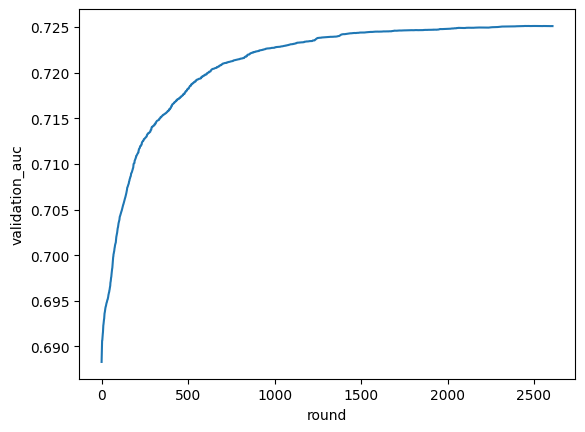

Validation ROC AUC: 0.7251
Validation Accuracy: 0.6838
Confusion matrix:
[[22490 30249]
 [14016 73245]]

Top 20 feature importances:


num__age_bin_x_fh_fact                     0.550477
num__TE_activity_bin_x_fh_fact             0.094826
num__physical_activity_minutes_per_week    0.041700
num__TE_bmi_bin_x_fh_fact                  0.041514
num__age                                   0.030981
num__family_history_diabetes               0.028485
num__triglycerides                         0.013395
num__bmi                                   0.010384
num__TE_age_bin_x_fh_fact                  0.009411
num__ldl_cholesterol                       0.008999
num__cardiovascular_history                0.008474
num__diet_score                            0.007250
num__hdl_cholesterol                       0.007000
num__heart_rate                            0.006898
num__waist_to_hip_ratio                    0.006436
num__activity_bin_x_fh_fact                0.006435
num__cholesterol_total                     0.006335
num__systolic_bp                           0.006046
ohe_cat__employment_status_Student         0.005658
num__screen_

In [28]:
# XGBoost baseline: train/validation split, fit, evaluate
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix

# Prepare features and target (X_train_trans is a DataFrame with target column already added)
X = X_train_trans.drop(columns=[TARGET])
y = X_train_trans[TARGET].astype(int)

# Stratified split to keep label proportions
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Small baseline classifier (adjust params as needed)
clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc', n_estimators=3000, max_depth=6, learning_rate=0.02, random_state=42, n_jobs=4,early_stopping_rounds=100,)


clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],  verbose=50)
res = clf.evals_result()
import matplotlib.pyplot as plt
plt.plot(res['validation_0']['auc'])
plt.xlabel('round'); plt.ylabel('validation_auc'); plt.show()
# Predict probabilities and classes on validation set
y_val_proba = clf.predict_proba(X_val)[:, 1]
y_val_pred = clf.predict(X_val)

# Metrics
roc = roc_auc_score(y_val, y_val_proba)
acc = accuracy_score(y_val, y_val_pred)
cm = confusion_matrix(y_val, y_val_pred)

print(f'Validation ROC AUC: {roc:.4f}')
print(f'Validation Accuracy: {acc:.4f}')
print('Confusion matrix:')
print(cm)

# Optional: feature importances (top 20)
try:
    importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    print('\nTop 20 feature importances:')
    display(importances)
except Exception:
    pass


In [16]:
np.std(y_val_proba), np.std(test_proba)

(0.18360238, 0.19774458)

In [21]:

# Optional: predict on test set and create a small submission dataframe
test_proba = clf.predict_proba(X_test_trans)[:,1]
submission = pd.DataFrame({'id': test['id'], 'probability': test_proba}).set_index('id')
submission.to_csv('submission_interaction_te_dropped_int_bins.csv')